In [1]:
%load_ext autoreload
%autoreload 2

In [2]:

import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geovisxrd


from geovisxrd.modeling.trainer import train_model
from geovisxrd.modeling.save import save_model
from geovisxrd.explaining.explainer import shapexplainer
from geovisxrd.explaining.io import save_shap_results, load_shap_results
from geovisxrd.explaining.visualization import plot_all_shap_charts
from geovisxrd.causal.discovery import get_causal_model
from geovisxrd.threshold.optimizer import analyze_threshold_stability
from geovisxrd.plotting.plotting import plot_causal_graph_networkx
from geovisxrd.plotting.plotting import plot_dependence_2d_lowess, plot_dependence_3d_interaction, plot_pos_neg_ratio

    

/Users/shumouren/miniconda3/envs/camp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing(as_frame=True)
X = data.data.iloc[:500, :]  # take first 500 samples for faster testing
y = data.target.iloc[:500]

print(f"SUCCESS: Data loaded. Features: {list(X.columns)}")

SUCCESS: Data loaded. Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [4]:
output_dirs = ["test_outputs/models", "test_outputs/shap", "test_outputs/causal/model", "test_outputs/stability",
               "test_outputs/causal/optimized","test_outputs/causal/pictures"]
for d in output_dirs:
    os.makedirs(d, exist_ok=True)


INFO: Testing model: RF
INFO: Training completed | RMSE: 0.3996
Save rf_20260122_223628.pkl to test_outputs/models/rf_20260122_223628.pkl
INFO: [GeoVisXRD] Detected model type: RandomForestRegressor ---
INFO: [GeoVisXRD] Using TreeExplainer (for tree models)...
INFO: [GeoVisXRD] Computing SHAP values (500 samples)...


SHAP computation progress: 100%|██████████| 1/1 [00:00<00:00,  1.27batch/s]


INFO: [GeoVisXRD] Computation complete, generating plot...
INFO: [GeoVisXRD] Plot saved to: test_outputs/shap/rf_summary.png
INFO: [GeoVisXRD] Complete data (binary) saved to: test_outputs/shap/rf_data/shap_20260122_223630.joblib
INFO: [GeoVisXRD] SHAP values table (CSV) saved to: test_outputs/shap/rf_data/csv_data/shap_20260122_223630.csv
INFO: [GeoVisXRD] Generating plots, saving to: test_outputs/shap/rf_plots/ 
INFO: 1. Plotting: Swarm Plot (Summary Dot)...
INFO: 2. Plotting: Importance Bar Chart (Summary Bar)...
INFO: 3. Plotting: Single Sample Waterfall Plot (Waterfall - Sample 0)...
SUCCESS: [GeoVisXRD] All plots generated successfully!

INFO: Testing model: XGB
INFO: Training completed | RMSE: 0.3753
Save xgb_20260122_223631.pkl to test_outputs/models/xgb_20260122_223631.pkl
INFO: [GeoVisXRD] Detected model type: XGBRegressor ---
INFO: [GeoVisXRD] Using TreeExplainer (for tree models)...
INFO: [GeoVisXRD] Computing SHAP values (500 samples)...


SHAP computation progress: 100%|██████████| 1/1 [00:00<00:00, 10.66batch/s]

INFO: [GeoVisXRD] Computation complete, generating plot...


...

INFO: [GeoVisXRD] Computation complete, generating plot...
INFO: [GeoVisXRD] Plot saved to: test_outputs/shap/mlp_summary.png
INFO: [GeoVisXRD] Complete data (binary) saved to: test_outputs/shap/mlp_data/shap_20260122_223645.joblib
INFO: [GeoVisXRD] SHAP values table (CSV) saved to: test_outputs/shap/mlp_data/csv_data/shap_20260122_223645.csv
INFO: [GeoVisXRD] Generating plots, saving to: test_outputs/shap/mlp_plots/ 
INFO: 1. Plotting: Swarm Plot (Summary Dot)...
INFO: 2. Plotting: Importance Bar Chart (Summary Bar)...
INFO: 3. Plotting: Single Sample Waterfall Plot (Waterfall - Sample 0)...
SUCCESS: [GeoVisXRD] All plots generated successfully!

INFO: Testing model: LINEAR
INFO: Training completed | RMSE: 0.4672
Save linear_20260122_223646.pkl to test_outputs/models/linear_20260122_223646.pkl
INFO: [GeoVisXRD] Detected model type: LinearRegression ---
INFO: [GeoVisXRD] Using LinearExplainer (for linear models)...
INFO: [GeoVisXRD] Computing SHAP values (500 samples)...


SHAP computation progress: 100%|██████████| 1/1 [00:00<00:00, 4293.04batch/s]

INFO: [GeoVisXRD] Computation complete, generating plot...


INFO: [GeoVisXRD] Plot saved to: test_outputs/shap/linear_summary.png
INFO: [GeoVisXRD] Complete data (binary) saved to: test_outputs/shap/linear_data/shap_20260122_223646.joblib
INFO: [GeoVisXRD] SHAP values table (CSV) saved to: test_outputs/shap/linear_data/csv_data/shap_20260122_223646.csv
INFO: [GeoVisXRD] Generating plots, saving to: test_outputs/shap/linear_plots/ 
INFO: 1. Plotting: Swarm Plot (Summary Dot)...
INFO: 2. Plotting: Importance Bar Chart (Summary Bar)...
INFO: 3. Plotting: Single Sample Waterfall Plot (Waterfall - Sample 0)...
SUCCESS: [GeoVisXRD] All plots generated successfully!

SUCCESS: All regression models tested!


,model,rmse
0,rf,0.399582
1,xgb,0.375326
2,lgb,0.326898
3,mlp,0.733120
4,linear,0.467170


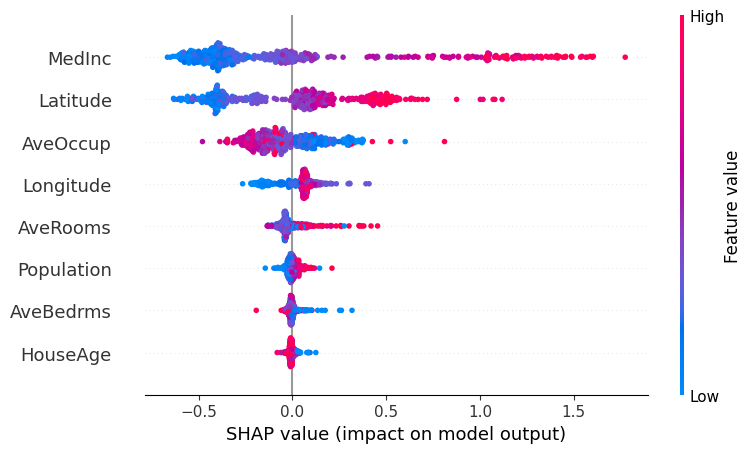

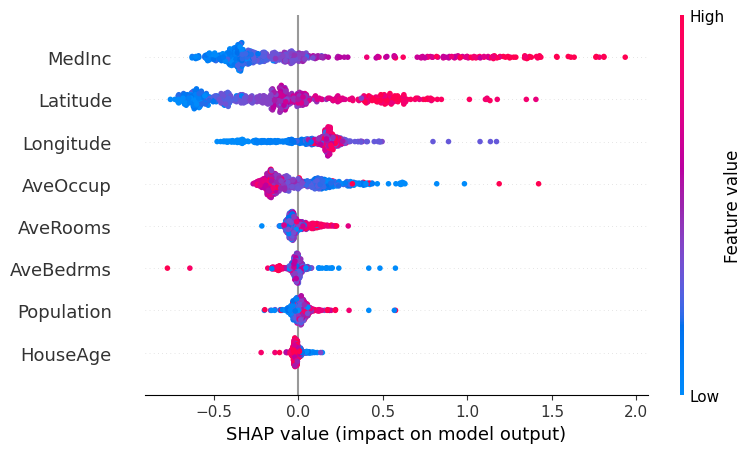

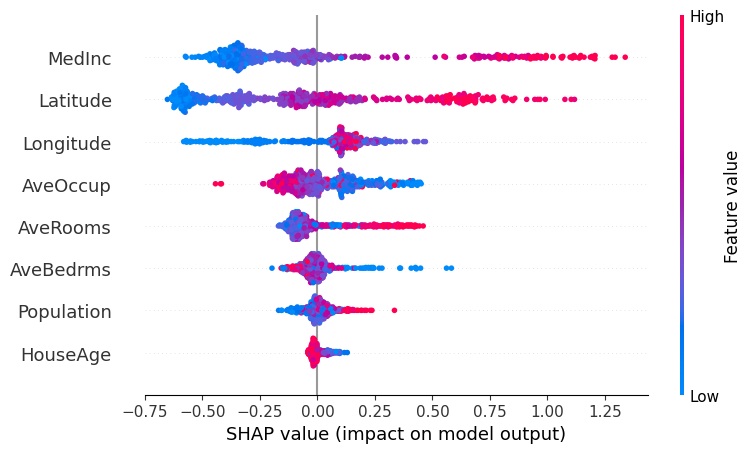

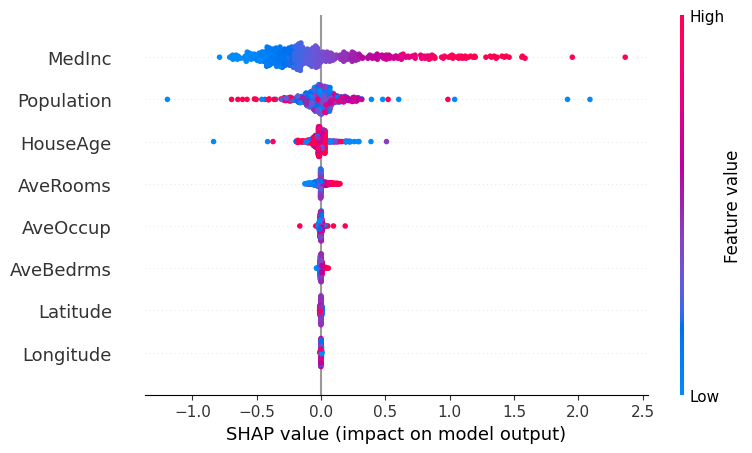

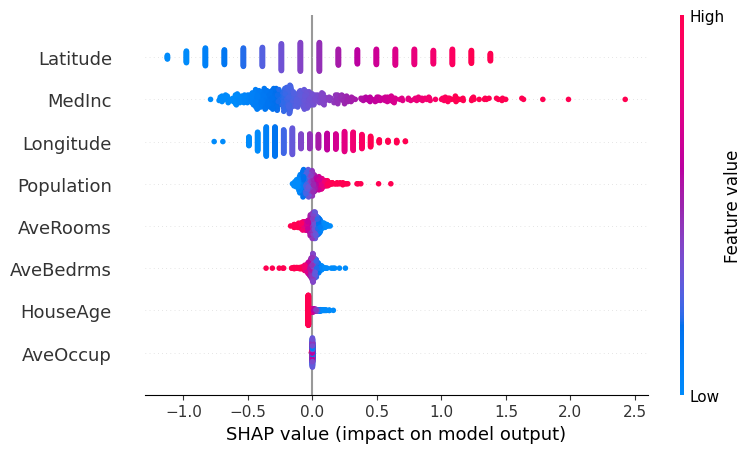

In [5]:
# 1. define configurations for each model to be tested
model_configs = {
    "rf": {
        "params": {"n_estimators": 100, "max_depth": 10, "random_state": 42}
    },
    "xgb": {
        "params": {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 6}
    },
    "lgb": {
        "params": {"n_estimators": 150, "num_leaves": 31, "learning_rate": 0.1}
    },
    "mlp": {
        "params": {"hidden_layer_sizes": (64, 32), "max_iter": 500, "random_state": 1}
    },
    "linear": {
        "params": {} # Linear regression usually does not require additional parameters
    }
}

results_summary = []

for m_name, config in model_configs.items():
    print(f"\n" + "="*50)
    print(f"INFO: Testing model: {m_name.upper()}")
    
    try:
        # 1. Train model - unpack config['params'] to pass specific hyperparameters
        # train_model will call get_model and pass these parameters through
        model, metrics = train_model(
            model_name=m_name, 
            X=X, 
            y=y, 
            **config['params']
        )
        
        results_summary.append({"model": m_name, "rmse": metrics['rmse']})
        print(f"INFO: Training completed | RMSE: {metrics['rmse']:.4f}")
        
        # 2. Save model
        save_model(model, m_name, save_dir="test_outputs/models")
        
        # 3. Calculate and save SHAP explanations
        explainer, shap_vals = shapexplainer(
            model, X, 
            save_path=f"test_outputs/shap/{m_name}_summary.png"
        )
        
        # 4. Save SHAP data (binary + CSV)
        save_shap_results(explainer, shap_vals, X, save_dir=f"test_outputs/shap/{m_name}_data")
        
        # 5. Generate full set of charts (using the constructed Explanation object)
        shap_dict = {"explainer": explainer, "shap_values": shap_vals, "X": X}
        plot_all_shap_charts(shap_dict, save_dir=f"test_outputs/shap/{m_name}_plots")
        
    except Exception as e:
        print(f"ERROR: Model {m_name} test failed: {e}")

print("\n" + "="*50)
print("SUCCESS: All regression models tested!")
import pandas as pd
display(pd.DataFrame(results_summary))

In [8]:
# ==================== manual configuration ====================
# 1. Specify the features to analyze (must be columns in X)
#MANUAL_X_FEATURE = "MedInc"    # X-axis: original feature values
#MANUAL_Y_FEATURE = "MedInc"    # Y-axis: corresponding contribution. Set the same name to analyze its own impact

# 2. For recursive analysis, to see the contribution of feature A to feature B:
MANUAL_X_FEATURE = "HouseAge"
MANUAL_Y_FEATURE = "MedInc"  # Observe how HouseAge changes the SHAP value of MedInc
MANUAL_INTERACTION_FEATURE = "Latitude"  # Optional: specify a third feature to observe interaction effects

# 3. Specify which model's SHAP results to load
SHAP_DATA_PATH = "test_outputs/shap/xgb_data/shap_20260122_223631.joblib" 

SAVE_PLOTS_DIR = "test_outputs/shap/xgb_plots/"
# ========================================================

In [9]:
# Load SHAP results
shap_data = load_shap_results(SHAP_DATA_PATH)
X = shap_data["X"]
shap_values = shap_data["shap_values"]

INFO: [GeoVisXRD] Loading SHAP data: test_outputs/shap/xgb_data/shap_20260122_223631.joblib ...


In [10]:
# 2.  Call advanced LOWESS plotting function
# Use the specified x_feature and y_feature
plot_dependence_2d_lowess(
    shap_values=shap_values, 
    X=X, 
    x_feature=MANUAL_X_FEATURE,  # Manually selected X axis
    y_feature=MANUAL_Y_FEATURE,  # Manually selected Y axis (source of contribution)
    save_path=f"{SAVE_PLOTS_DIR}/manual_lowess_{MANUAL_X_FEATURE}_vs_{MANUAL_Y_FEATURE}.png",
    lower=0.01, # Filter out 1% low quantile outliers
    upper=0.99  # Filter out 1% high quantile outliers
)

# 3. Synchronously generate positive and negative contribution ratio plots to assist in judging feature nature
plot_pos_neg_ratio(
    shap_values,
    X.columns, 
    save_path=f"{SAVE_PLOTS_DIR}/manual_pos_neg_ratio.png"
)

INFO: Plotting 2D Lowess: X=HouseAge, Y=SHAP(MedInc) ...
   - Saved: test_outputs/shap/xgb_plots//manual_lowess_HouseAge_vs_MedInc.png
INFO: Plotting Ratio Plot (test_outputs/shap/xgb_plots//manual_pos_neg_ratio.png)...


/Users/shumouren/miniconda3/envs/camp/lib/python3.10/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


<Axes: title={'center': 'Positive and Negative Ratios per Feature'}, xlabel='Ratio'>

In [11]:
# 4. 3D display of how HouseAge modulates the contribution of MedInc
plot_dependence_3d_interaction(
    shap_values=shap_values, 
    X=X, 
    x_feature=MANUAL_X_FEATURE,
    y_feature=MANUAL_Y_FEATURE,
    interaction_feature=MANUAL_INTERACTION_FEATURE,
    save_path=f"{SAVE_PLOTS_DIR}/MedInc_HouseAge_interaction.png"
)

INFO: Plotting 3D Interaction: X=HouseAge, Y=SHAP(MedInc), Color=Latitude ...
INFO: Saved: test_outputs/shap/xgb_plots//MedInc_HouseAge_interaction.png


# Causal Discovery #

In [12]:
# 1. define specific configurations for each causal discovery model
causal_configs = {
    "sam": {
        "params": {
            "nruns": 8,              # Reduce number of runs (default 8), most effective speed-up
            "train_epochs": 100,      # Corrected parameter name: training epochs (original n_epochs caused error)
            "test_epochs": 100,       # Corrected parameter name: testing epochs
            "nh": 10,                # Reduce number of hidden layer nodes to lessen computation
            "lr": 0.01,              # Learning rate
            "batch_size": 128        # Increase batch size to improve efficiency
        }
    },
    "lingam": {"params": {}},  
    "notears": {"params": {"threshold": 0.15}},  
    "pc": {"params": {"alpha": 0.05}}  
}

causal_models = {}

for method, config in causal_configs.items():
    print(f"\nINFO: Running causal discovery algorithm: {method.upper()}")
    
    try:
        # 1. Initialize model with specific parameters
        c_model = get_causal_model(method=method, **config['params'])
        
        # 2. Fit data
        # Note: SAM training is very CPU/GPU intensive, ensure cdt library is installed
        c_model.fit(X)
        causal_models[method] = c_model
        
        # 3. Save model file (including complete graph structure and metadata)
        model_save_path = f"test_outputs/causal/model/{method}_model.pkl"
        c_model.save(model_save_path)
        print(f"INFO: Model saved to: {model_save_path}")
        
        # 4. Get graph object and perform initial plotting
        nx_graph = c_model.get_nx_graph()
        plot_causal_graph_networkx(
            nx_graph, 
            threshold=0.01, 
            title=f"Causal Discovery ({method})",
            save_path=f"test_outputs/causal/{method}_initial_graph.png"
        )
        
    except Exception as e:
        print(f"ERROR: {method} failed to run: {e}")


INFO: Running causal discovery algorithm: SAM
INFO: SAM (Structural Agnostic Model)


No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.
100%|██████████| 200/200 [00:10<00:00, 18.85it/s, disc=-0.255, gen=-1.17, regul_loss=0.38, tot=-8.22]  


INFO: SAM training finished.
SUCCESS: Causal model saved to: test_outputs/causal/model/sam_model.pkl
INFO: Model saved to: test_outputs/causal/model/sam_model.pkl
INFO: Plotting causal graph (Threshold=0.01)...
INFO: Plot saved: test_outputs/causal/sam_initial_graph.png

INFO: Running causal discovery algorithm: LINGAM
INFO: LiNGAM
INFO: LiNGAM training finished.
SUCCESS: Causal model saved to: test_outputs/causal/model/lingam_model.pkl
INFO: Model saved to: test_outputs/causal/model/lingam_model.pkl
INFO: Plotting causal graph (Threshold=0.01)...
INFO: Plot saved: test_outputs/causal/lingam_initial_graph.png

INFO: Running causal discovery algorithm: NOTEARS
INFO: NOTEARS
INFO: NOTEARS training finished.
SUCCESS: Causal model saved to: test_outputs/causal/model/notears_model.pkl
INFO: Model saved to: test_outputs/causal/model/notears_model.pkl
INFO: Plotting causal graph (Threshold=0.01)...
INFO: Plot saved: test_outputs/causal/notears_initial_graph.png

INFO: Running causal discovery

Depth=3, working on node 7: 100%|██████████| 8/8 [00:00<00:00, 1106.46it/s]

INFO: PC training finished.
SUCCESS: Causal model saved to: test_outputs/causal/model/pc_model.pkl
INFO: Model saved to: test_outputs/causal/model/pc_model.pkl
INFO: Plotting causal graph (Threshold=0.01)...


INFO: Plot saved: test_outputs/causal/pc_initial_graph.png


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Core logic for stability analysis (combining ideas from files 07 and 08)
print("\n" + "="*50)
print("INFO: Running causal graph stability deep optimization...")

# Optimization records
stability_results = []

# Iterate over all trained causal model objects
for method, c_model in causal_models.items():
    print(f"\nINFO: Processing model: {method.upper()}")
    
    try:
        # Refer to file 08: Calculate dynamic threshold stability
        # analyze_threshold_stability calculates J(G_t, G_{t-0.1})
        df_stability, best_t = analyze_threshold_stability(
            data_input=c_model, 
            threshold_range=np.arange(0.1, 0.81, 0.05),
            save_path=f"test_outputs/stability/{method}_stability_curve.png"
        )
        
        # Get Jaccard data (refer to logic in file 07)
        peak_jaccard = df_stability['Jaccard'].max()
        print(f"INFO: Optimization result: Best threshold t={best_t:.2f}, Max stability J={peak_jaccard:.4f}")

        # 2. Reconstruct causal graph based on optimized best_t
        # This step automatically filters weak edges, retaining the most stable structure
        nx_graph = c_model.get_nx_graph()
        final_edges = plot_causal_graph_networkx(
            nx_graph, 
            threshold=best_t, 
            title=f"Optimized Causal Structure: {method} (t={best_t})",
            save_path=f"test_outputs/causal/optimized/{method}_final_optimized.png",
            show=False # Batch run, do not pop up window
        )
        
        stability_results.append({
            "Method": method,
            "Best_Threshold": best_t,
            "Max_Stability": peak_jaccard,
            "Remaining_Edges": len(final_edges)
        })
        
    except Exception as e:
        print(f"ERROR: {method} stability analysis failed: {e}")

# 3. Summary display
print("\n" + "="*50)
print("INFO: Summary of optimal thresholds for each causal model:")
summary_df = pd.DataFrame(stability_results)
display(summary_df)


INFO: Running causal graph stability deep optimization...

INFO: Processing model: SAM
INFO: Extracting weights from the saved model and performing dynamic threshold segmentation...
   - [t=0.2 vs 0.1] Stability: 1.0000
   - [t=0.2 vs 0.1] Stability: 1.0000
   - [t=0.3 vs 0.2] Stability: 1.0000
   - [t=0.3 vs 0.2] Stability: 1.0000
   - [t=0.4 vs 0.3] Stability: 1.0000
   - [t=0.4 vs 0.3] Stability: 1.0000
   - [t=0.5 vs 0.4] Stability: 0.9821
   - [t=0.5 vs 0.4] Stability: 1.0000
   - [t=0.6 vs 0.5] Stability: 0.7636
   - [t=0.6 vs 0.5] Stability: 1.0000
   - [t=0.7 vs 0.6] Stability: 0.6429
   - [t=0.7 vs 0.6] Stability: 1.0000
   - [t=0.8 vs 0.7] Stability: 0.6667
   - [t=0.8 vs 0.7] Stability: 1.0000
INFO: Curve chart generated: test_outputs/stability/sam_stability_curve.png
INFO: Optimization result: Best threshold t=0.20, Max stability J=1.0000
INFO: Plotting causal graph (Threshold=0.2)...
INFO: Plot saved: test_outputs/causal/optimized/sam_final_optimized.png

INFO: Processing

,Method,Best_Threshold,Max_Stability,Remaining_Edges
0,sam,0.2,1.0,56
1,lingam,0.2,1.0,9
2,notears,0.2,1.0,25
3,pc,0.2,1.0,20


# recursive training #
## second layer ##

In [17]:
from geovisxrd.recursive.pipeline import run_recursive_step

file_path = SHAP_DATA_PATH

# setup for layer 2 recursive step
path_layer2 = run_recursive_step(
    layer_num=2, 
    previous_shap_path=file_path, 
    target_feature_name="MedInc"
)

INFO: [GeoVisXRD] Starting layer 2 analysis: MedInc ---
INFO: Results will be saved to: /Users/shumouren/Downloads/GeoVisXRD/example/test_outputs/shap/xgb_data/layer_2_MedInc
INFO: [GeoVisXRD] Loading SHAP data: test_outputs/shap/xgb_data/shap_20260122_223631.joblib ...
Save layer2_xgb_20260122_224119.pkl to /Users/shumouren/Downloads/GeoVisXRD/example/test_outputs/shap/xgb_data/layer_2_MedInc/models/layer2_xgb_20260122_224119.pkl
INFO: [GeoVisXRD] Detected model type: XGBRegressor ---
INFO: [GeoVisXRD] Using TreeExplainer (for tree models)...
INFO: [GeoVisXRD] Computing SHAP values (500 samples)...


SHAP computation progress: 100%|██████████| 1/1 [00:00<00:00, 43.59batch/s]

INFO: [GeoVisXRD] Computation complete, generating plot...


INFO: [GeoVisXRD] Plot saved to: /Users/shumouren/Downloads/GeoVisXRD/example/test_outputs/shap/xgb_data/layer_2_MedInc/shap_summary.png
INFO: [GeoVisXRD] Complete data (binary) saved to: /Users/shumouren/Downloads/GeoVisXRD/example/test_outputs/shap/xgb_data/layer_2_MedInc/shap_data/layer2_20260122_224119.joblib
INFO: [GeoVisXRD] SHAP values table (CSV) saved to: /Users/shumouren/Downloads/GeoVisXRD/example/test_outputs/shap/xgb_data/layer_2_MedInc/shap_data/csv_data/layer2_20260122_224119.csv
INFO: SAM (Structural Agnostic Model)


100%|██████████| 1100/1100 [01:04<00:00, 16.93it/s, disc=2.42, gen=-0.357, regul_loss=0.34, tot=2.13]   


INFO: SAM training finished.
INFO: Extracting weights from the saved model and performing dynamic threshold segmentation...
   - [t=0.2 vs 0.1] Stability: 1.0000
   - [t=0.3 vs 0.2] Stability: 1.0000
   - [t=0.4 vs 0.3] Stability: 0.1111
   - [t=0.5 vs 0.4] Stability: 0.2500
   - [t=0.6 vs 0.5] Stability: 0.0000
   - [t=0.7 vs 0.6] Stability: 1.0000
   - [t=0.8 vs 0.7] Stability: 1.0000
   - [t=0.9 vs 0.8] Stability: 1.0000
   - [t=1.0 vs 0.9] Stability: 1.0000
INFO: Curve chart generated: /Users/shumouren/Downloads/GeoVisXRD/example/test_outputs/shap/xgb_data/layer_2_MedInc/stability_curve.png
INFO: Plotting causal graph (Threshold=0.2)...
INFO: Plot saved: /Users/shumouren/Downloads/GeoVisXRD/example/test_outputs/shap/xgb_data/layer_2_MedInc/final_causal_graph.png
INFO: [GeoVisXRD] Analysis complete. Next layer data path: /Users/shumouren/Downloads/GeoVisXRD/example/test_outputs/shap/xgb_data/layer_2_MedInc/shap_data/layer2_20260122_224119.joblib ---


In [18]:
# take HouseAge as a example
path_layer3 = run_recursive_step(
    layer_num=3, 
    previous_shap_path=path_layer2, # Automatically pass the file generated in the previous layer
    target_feature_name="HouseAge"
)

INFO: [GeoVisXRD] Starting layer 3 analysis: HouseAge ---
INFO: Results will be saved to: /Users/shumouren/Downloads/GeoVisXRD/example/test_outputs/shap/xgb_data/layer_2_MedInc/shap_data/layer_3_HouseAge
INFO: [GeoVisXRD] Loading SHAP data: /Users/shumouren/Downloads/GeoVisXRD/example/test_outputs/shap/xgb_data/layer_2_MedInc/shap_data/layer2_20260122_224119.joblib ...
Save layer3_xgb_20260122_224230.pkl to /Users/shumouren/Downloads/GeoVisXRD/example/test_outputs/shap/xgb_data/layer_2_MedInc/shap_data/layer_3_HouseAge/models/layer3_xgb_20260122_224230.pkl
INFO: [GeoVisXRD] Detected model type: XGBRegressor ---
INFO: [GeoVisXRD] Using TreeExplainer (for tree models)...
INFO: [GeoVisXRD] Computing SHAP values (500 samples)...


SHAP computation progress: 100%|██████████| 1/1 [00:00<00:00, 112.18batch/s]

INFO: [GeoVisXRD] Computation complete, generating plot...


INFO: [GeoVisXRD] Plot saved to: /Users/shumouren/Downloads/GeoVisXRD/example/test_outputs/shap/xgb_data/layer_2_MedInc/shap_data/layer_3_HouseAge/shap_summary.png
INFO: [GeoVisXRD] Complete data (binary) saved to: /Users/shumouren/Downloads/GeoVisXRD/example/test_outputs/shap/xgb_data/layer_2_MedInc/shap_data/layer_3_HouseAge/shap_data/layer3_20260122_224230.joblib
INFO: [GeoVisXRD] SHAP values table (CSV) saved to: /Users/shumouren/Downloads/GeoVisXRD/example/test_outputs/shap/xgb_data/layer_2_MedInc/shap_data/layer_3_HouseAge/shap_data/csv_data/layer3_20260122_224230.csv
INFO: SAM (Structural Agnostic Model)


100%|██████████| 1100/1100 [01:05<00:00, 16.81it/s, disc=145, gen=-142, regul_loss=0.5, tot=-1.26e+3]        


INFO: SAM training finished.
INFO: Extracting weights from the saved model and performing dynamic threshold segmentation...
   - [t=0.2 vs 0.1] Stability: 1.0000
   - [t=0.3 vs 0.2] Stability: 1.0000
   - [t=0.4 vs 0.3] Stability: 0.4444
   - [t=0.5 vs 0.4] Stability: 0.0000
   - [t=0.6 vs 0.5] Stability: 1.0000
   - [t=0.7 vs 0.6] Stability: 1.0000
   - [t=0.8 vs 0.7] Stability: 1.0000
   - [t=0.9 vs 0.8] Stability: 1.0000
   - [t=1.0 vs 0.9] Stability: 1.0000
INFO: Curve chart generated: /Users/shumouren/Downloads/GeoVisXRD/example/test_outputs/shap/xgb_data/layer_2_MedInc/shap_data/layer_3_HouseAge/stability_curve.png
INFO: Plotting causal graph (Threshold=0.2)...
INFO: Plot saved: /Users/shumouren/Downloads/GeoVisXRD/example/test_outputs/shap/xgb_data/layer_2_MedInc/shap_data/layer_3_HouseAge/final_causal_graph.png
INFO: [GeoVisXRD] Analysis complete. Next layer data path: /Users/shumouren/Downloads/GeoVisXRD/example/test_outputs/shap/xgb_data/layer_2_MedInc/shap_data/layer_3_House